In [74]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os, json, cv2
%matplotlib inline


In [75]:
depth_scale = 1000.0

# 加载数据
depth = np.load('E:/HKUSTGZ/AAM/perception/result/1st_capturing/20260310_132249.npy')
img = cv2.imread('E:/HKUSTGZ/AAM/perception/result/1st_capturing/20260310_132249.png')
mask = np.load('E:/HKUSTGZ/AAM/perception/result/1st_capturing/mask.npy')
intrinsic_mtx = np.load('E:/HKUSTGZ/AAM/相机标定/右相机/内参标定/R_camera_paras.npy', allow_pickle = True)
hand_eye_R = np.load('E:/HKUSTGZ/AAM/相机标定/右相机/手眼标定/hand_eye_result_R.npy', allow_pickle = True)
hand_eye_T = np.load('E:/HKUSTGZ/AAM/相机标定/右相机/手眼标定/hand_eye_result_T.npy', allow_pickle = True)
e_T_c = np.concatenate((hand_eye_R,hand_eye_T),axis = 1)
e_T_c =np.concatenate((e_T_c,np.array([[0,0,0,1]])),axis = 0)

intrinsic_mtx = intrinsic_mtx.item()
K = intrinsic_mtx['intrinsic_mtx:']
dist = intrinsic_mtx['dist']
fx = K[0,0]
fy = K[1,1]
cx = K[0,-1]
cy = K[1,-1]

mask = mask[0]
# 确保深度图是 float32 并转换为米
if depth.dtype == np.uint16:
    depth = depth.astype(np.float32) / depth_scale
elif depth.dtype == np.uint8:
    depth = depth.astype(np.float32) * 0.01  # 假设是 0-255 -> 0-2.55m

# 创建网格坐标 (u, v)
H, W = depth.shape
v_coords, u_coords = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')

# 提取有效点的像素坐标和深度值
u_valid = u_coords[mask]
v_valid = v_coords[mask]
d_valid = depth[mask]

u_valid = u_valid[d_valid > 0] # 注意：这里也要同步过滤u和v，否则坐标对不上
v_valid = v_valid[d_valid > 0]
d_valid = d_valid[d_valid > 0]


# 反投影到相机坐标系 (X, Y, Z)
# 公式: X = (u - cx) * Z / fx, Y = (v - cy) * Z / fy, Z = d
# fx, fy 是相机内参
Z_cam = d_valid
X_cam = (u_valid - cx) * Z_cam / fx
Y_cam = (v_valid - cy) * Z_cam / fy

# 构建点云矩阵 N x 3
points = np.stack([X_cam, Y_cam, Z_cam], axis=1)  # shape: (N, 3)

print(f"点云数量: {points.shape[0]}")



In [77]:
# ==================== PCA 分析 ====================
# 1. 计算质心
centroid = np.mean(points, axis=0)
print("质心 (相机坐标系):", centroid)
# 2. 去中心化
points_centered = points - centroid
# 3. 计算协方差矩阵
cov_matrix = np.cov(points_centered, rowvar=False)  # 3x3
# 4. 特征值分解
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)  # eigh 用于对称矩阵，更稳定
# 按特征值降序排列
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]  # 每列是一个特征向量
# 5. 构建旋转矩阵（确保右手系）
R_pca = eigenvectors.copy()
if np.linalg.det(R_pca) < 0:
    R_pca[:, -1] *= -1  # 翻转最小特征值对应的轴，保证行列式为+1

print("特征值（方差大小）:", eigenvalues)
print("主轴方向X,Y,Z（列向量）:\n", R_pca)

# 6. 定义物体局部坐标系轴（在相机坐标系下）
object_x_axis = R_pca[:, 0]  # 最长轴 → 通常作为物体的“前向”或“长边”
object_y_axis = R_pca[:, 1]  # 次长轴
object_z_axis = R_pca[:, 2]  # 最短轴 → 通常垂直于物体平面

# ==================== 输出结果 ====================
pose_initial = {
    'translation': centroid.tolist(),
    'rotation_matrix': R_pca.tolist(),
    'axes': {
        'x': object_x_axis.tolist(),
        'y': object_y_axis.tolist(),
        'z': object_z_axis.tolist()
    },
    'eigenvalues': eigenvalues.tolist()
}

质心 (相机坐标系): [-0.16313925 -0.06008033  0.42861479]
特征值（方差大小）: [2.85388585e-04 2.28217265e-04 2.23872628e-05]
主轴方向X,Y,Z（列向量）:
 [[-0.99584028 -0.09029308 -0.01221854]
 [-0.04515353  0.6055165  -0.79455077]
 [ 0.07914097 -0.79069396 -0.60707477]]


In [78]:
## 确认Z轴在世界中的朝向：上还是下
rotation_mtx_end_base_path = 'E:/HKUSTGZ/AAM/相机标定/右相机/手眼标定/hand_eye_result_R.npy'
rotation_mtx_end_base = np.load(rotation_mtx_end_base_path)
object_z_base = rotation_mtx_end_base @ object_z_axis

# 若object Z axis相对世界朝下，反转坐标系
if object_z_base[2] < 0:
    object_z_axis = -object_z_axis
    object_x_axis = -object_x_axis
    print('reverse axises')

reverse axises


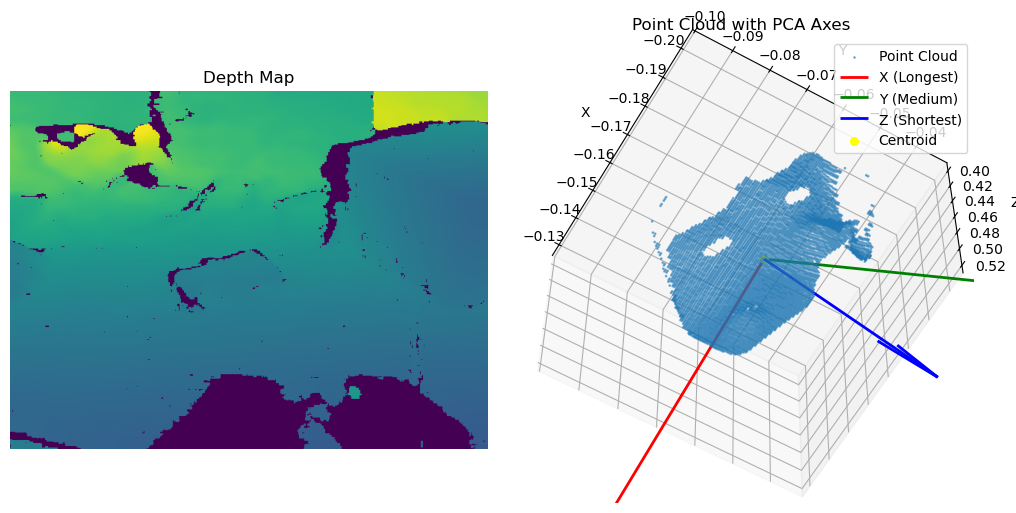

In [85]:
# ==================== 可视化（可选）====================
fig = plt.figure(figsize=(10, 5))

# 子图1：原始深度图
ax1 = fig.add_subplot(121)
ax1.imshow(depth, cmap='viridis')
ax1.set_title("Depth Map")
ax1.axis('off')

# 子图2：点云 + PCA轴
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(points[:, 0], points[:, 1], points[:, 2], s=1, alpha=0.5, label='Point Cloud')

# 画三个主轴（长度按比例缩放）
scale = 0.2  # 缩放系数便于可视化
ax2.quiver(*centroid, *object_x_axis*scale, color='r', linewidth=2, label='X (Longest)')
ax2.quiver(*centroid, *object_y_axis*scale, color='g', linewidth=2, label='Y (Medium)')
ax2.quiver(*centroid, *object_z_axis*scale*0.3, color='b', linewidth=2, label='Z (Shortest)')
# 画质心
ax2.scatter(*centroid, color='yellow', s=30, label='Centroid')

ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title('Point Cloud with PCA Axes')
ax2.legend()
ax2.view_init(elev=120, azim=30) # 120, 30

plt.tight_layout()
plt.show()

In [92]:
## 计算相机的水平视角场
HFOV = 2*np.arctan(640/(2*fx))  # image width / 2fx
HFOV_degrees = np.degrees(HFOV)

points_object = []
# 粗略计算物品的长宽高
for point in points:
    p_oject = R_pca @ (point-centroid)
    points_object.append(p_oject)
points_object = np.array(points_object)
object_len = max(points_object[:,0]) - min(points_object[:,0])
object_width = max(points_object[:,1]) - min(points_object[:,1])
object_height = max(points_object[:,2]) - min(points_object[:,2])
#计算拍摄距离
top_D = max([object_len,object_width, object_height])*1.1 / (2*np.tan(HFOV/2))
# side_D = 

In [96]:
# 拍摄俯视图，指导相机移动到合理位置
top_view_camera_position = centroid + object_z_axis * top_D
z_axis = -object_z_axis  # 相机光轴指向物体中心
x_axis = object_x_axis   # 尝试让相机的X轴对齐物体的长轴（可选，取决于你想怎么拍）
y_axis = np.cross(z_axis, x_axis)
y_axis = y_axis / np.linalg.norm(y_axis)
# 重新计算 X = Y cross Z (确保完全正交)
x_axis = np.cross(y_axis, z_axis)
x_axis = x_axis / np.linalg.norm(x_axis)

# 组装旋转矩阵 (列向量形式)
R_target = np.column_stack((x_axis, y_axis, z_axis))

# 5. 最终位姿矩阵 (4x4)
T_target = np.eye(4)
T_target[:3, 3] = top_view_camera_position  # 平移
T_target[:3, :3] = R_target        # 旋转

# 把旋转矩阵通过外参变换为机械臂endpose
c_T_e = np.linalg.inv(e_T_c)
T_robot_target = T_target @ c_T_e
x, y, z = T_robot_target[:3, 3]
R = T_robot_target[:3, :3]
from scipy.spatial.transform import Rotation as R_scipy
r = R_scipy.from_matrix(R)
rx, ry, rz = r.as_euler('xyz', degrees=False) # 输出为弧度

ModuleNotFoundError: No module named 'scipy'